<a href="https://colab.research.google.com/github/Madhankumarr11/Guvi_M59_Class/blob/main/Copy_of_AirBnB_Listings_Data_%E2%80%93_Daily_Work_of_a_Data_Team.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AirBnB Listings Data – Daily Work of a Data Team

**Internal Assignment — Listings Data Unification & Market Intelligence**

**Team:** Listings Intelligence & Data Platform

**Reporting To:** Senior Analytics Manager

**Role Context:** Data Engineer / Data Analyst
(Onboarding Sprint)

**Sprint Duration:** 1 Work Cycle

![](https://i.abcnewsfe.com/a/9ee38b15-e63b-4ee7-bc8b-b4f6d397bde8/airbnb-1-gty-er-250514_1747236947229_hpMain.jpg)
---

## Background

AirBnB’s listings data originates from multiple ingestion pipelines including host apps, pricing services, review systems, and partner integrations.
These pipelines publish data in different formats and storage systems.

Your responsibility in this sprint is to **reconstruct a reliable, analysis-ready listings dataset** that can be consumed by downstream pricing, growth, and trust teams.

This task reflects **live operational work** performed by AirBnB data teams.

---

## Data Assets Provided

You have access to AirBnB listings data exported from multiple internal systems:

| Source System               | Format  |
| --------------------------- | ------- |
| Listings Export Service     | CSV     |
| Partner Sync API            | JSON    |
| Operations Reporting        | Excel   |
| Feature Store Snapshot      | Pickle  |
| Analytics Warehouse Extract | Parquet |
| Web Reporting Tool          | HTML    |
| Internal SQLite Store       | SQL     |
| Configuration Dump          | YAML    |

Each source contains **overlapping listing records** with expected data quality issues.


# SEGMENT 1 — DATA INGESTION & SOURCE ALIGNMENT

**Focus:** Reliability, Compatibility, Data Engineering Discipline

---

## Objective

Ingest listing data from multiple internal AirBnB systems, each emitting data in different formats.
Align all sources into a consistent schema to support downstream quality validation and analytics.

All ingestion must be performed using **Pandas DataFrames**.

---

## Tasks (1–10)

---

### Task 1 — Load Listings Export (CSV)

**Description**
Load the Listings Export file generated by the core Listings Platform service.
This file represents the baseline schema used across AirBnB.

**Expected Outcome**
A Pandas DataFrame containing all listing records from the CSV source with no unintended type coercion.

**Hints**

* Use `pd.read_csv()`
* Avoid automatic date parsing during load
* Inspect column names and data types immediately using `info()`

---

### Task 2 — Ingest Partner Sync Data (JSON)

**Description**
Load listing data produced by the Partner Sync API.
Each record is stored on a separate line.

**Expected Outcome**
A DataFrame where each row represents a listing record, aligned to the CSV schema.

**Hints**

* Use `pd.read_json()` with line-based parsing
* Validate row count after ingestion
* Compare column coverage with the CSV source

---

### Task 3 — Load Operations Reporting (Excel)

**Description**
Load the Excel report used by Operations teams for internal monitoring.
Ensure only the relevant worksheet is ingested.

**Expected Outcome**
A DataFrame containing listing-level data without auxiliary or summary sheets.

**Hints**

* Use `pd.read_excel()`
* Inspect available sheet names before loading
* Avoid loading unnecessary sheets into memory

---

### Task 4 — Restore Feature Store Snapshot (Pickle)

**Description**
Restore the serialized snapshot produced by the Feature Store pipeline.

**Expected Outcome**
A DataFrame restored exactly as it was persisted, including data types.

**Hints**

* Use `pd.read_pickle()`
* Verify column count and data types
* Compare structure with previously loaded sources

---

### Task 5 — Load Analytics Warehouse Extract (Parquet)

**Description**
Load the Parquet extract generated from the Analytics Warehouse.

**Expected Outcome**
A DataFrame with optimized numeric and categorical data types.

**Hints**

* Use `pd.read_parquet()`
* Inspect memory usage after load
* Validate precision for price and review fields

---

### Task 6 — Parse Web Reporting Export (HTML)

**Description**
Extract listing data from the HTML export used in internal reporting dashboards.

**Expected Outcome**
A DataFrame constructed from the correct HTML table containing listing records.

**Hints**

* Use `pd.read_html()`
* Identify the correct table index
* Rename columns if auto-generated names are present

---

### Task 7 — Load Internal Listings Table (SQL)

**Description**
Connect to the internal SQLite store and extract the listings table.

**Expected Outcome**
A DataFrame representing the SQL table with correct column mapping.

**Hints**

* Use `sqlalchemy.create_engine()`
* Use `pd.read_sql()`
* Prefer explicit column selection over wildcard queries

---

### Task 8 — Normalize Configuration Dump (YAML)

**Description**
Load the YAML configuration dump and transform it into a tabular format suitable for analysis.

**Expected Outcome**
A DataFrame where each row corresponds to a listing record.

**Hints**

* Use the `yaml` library to read the file
* Convert nested structures into dictionaries
* Use `pd.DataFrame()` to normalize records

---

### Task 9 — Standardize Column Names Across Sources

**Description**
Different systems use slightly different naming conventions.
Standardize all column names before merging datasets.

**Expected Outcome**
All DataFrames share identical column names and ordering.

**Hints**

* Convert names to lowercase
* Replace spaces with underscores
* Apply renaming consistently across all DataFrames

---

### Task 10 — Consolidate All Sources into a Master Dataset

**Description**
Combine all ingested DataFrames into a single unified listings dataset.

**Expected Outcome**
A consolidated DataFrame representing all records across ingestion paths.

**Hints**

* Use `pd.concat()` for vertical combination
* Reset index after concatenation
* Validate final row count against expected totals

---

## Segment 1 Deliverable

* Individual DataFrames for each source
* One consolidated listings DataFrame
* A brief note summarizing ingestion issues and resolutions

---




In [ ]:
!unzip "/content/airbnb_listings_files.zip"

unzip:  cannot find or open /content/airbnb_listings_files.zip, /content/airbnb_listings_files.zip.zip or /content/airbnb_listings_files.zip.ZIP.


In [ ]:
!unzip "/content/airbnb_listings_files.zip" -d "/content/sample_data"

unzip:  cannot find or open /content/airbnb_listings_files.zip, /content/airbnb_listings_files.zip.zip or /content/airbnb_listings_files.zip.ZIP.


In [ ]:
!pip install pandas

In [ ]:
import pandas as pd

In [ ]:
df_csv = pd.read_csv('/content/airbnb_data.csv')
df_csv.head()

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1017814,Lakshmi,Pune,Shared room,2000.0,2.0,25,0.5,145,2024-05-04,Yes,Flexible
1,1006858,Karthik,Pune,Entire home,12000.0,2.0,20,0.0,313,2024-10-10,No,Moderate
2,1007673,Ananya,Chennai,Entire home,1500.0,2.0,29,0.5,107,2022-03-11,No,Flexible
3,1009705,Ravi,Hyderabad,Hotel room,500.0,3.0,29,2.5,303,2022-06-24,No,Flexible
4,1014304,NaN,Bangalore,Entire home,1500.0,3.0,33,0.0,138,2022-03-16,No,Flexible


In [ ]:
df_csv.shape

(4375, 12)

In [ ]:
df_xlsx = pd.read_excel('/content/airbnb_data.xlsx')
df_xlsx.head()
df_xlsx.shape

(4375, 12)

In [ ]:
df_html = pd.read_html('/content/airbnb_data.html')
len(df_html)
df_html[0]


,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1025064,NaN,Mumbai,Entire home,2000.0,1.0,46,0.5,119,2022-07-21,No,Flexible
1,1026745,Lakshmi,Kolkata,Entire home,2000.0,1.0,32,NaN,302,2022-04-25,No,Moderate
2,1023843,Ananya,Ahmedabad,Private room,1000.0,2.0,36,4.0,74,2023-08-03,No,Strict
3,1012763,Ananya,chennai,Hotel room,5000.0,1.0,49,1.2,269,2024-03-09,No,Flexible
4,1010524,Lakshmi,Bangalore,Shared room,NaN,1.0,34,0.0,12,2022-02-26,Yes,Strict
...,...,...,...,...,...,...,...,...,...,...,...,...
4370,1014034,John,chennai,Entire home,1500.0,7.0,45,NaN,326,2023-06-29,No,Moderate
4371,1026029,Ananya,Chennai,Shared room,1500.0,1.0,24,0.5,5,2023-10-10,No,Moderate
4372,1002150,Meena,Chennai,Shared room,2000.0,5.0,33,2.5,256,2024-03-04,No,Flexible
4373,1024896,Lakshmi,Ahmedabad,Private room,1500.0,1.0,28,4.0,314,2023-08-22,No,Strict


In [ ]:
df_json = pd.read_json('/content/airbnb_data.json', lines=True)
df_json.head()
df_json.shape

(4375, 12)

In [ ]:
df_parq = pd.read_parquet('/content/airbnb_data.parquet')
df_parq.head()

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
17500,1027117,John,Chennai,Private room,3000.0,3.0,38,2.5,78,2024-06-24,No,Flexible
17501,1010159,Ravi,Bangalore,Entire home,2000.0,2.0,35,0.0,71,2022-10-13,No,Flexible
17502,1024460,Ananya,Bangalore,Private room,2000.0,2.0,34,2.5,131,2024-04-25,Yes,Moderate
17503,1002479,Meena,chennai,Entire home,2000.0,5.0,44,0.0,65,2022-02-26,No,Moderate
17504,1003801,None,Ahmedabad,Entire home,500.0,1.0,24,0.0,192,2022-04-08,No,Moderate


In [ ]:
df_pkle = pd.read_pickle('/content/airbnb_data.pkl')
df_pkle.head()

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
13125,1026825,Karthik,Chennai,Entire home,2500,7,41,2.5,266,2024-03-09,No,Flexible
13126,1023441,John,Bangalore,Private room,500,1,36,0.0,212,2023-02-21,No,Flexible
13127,1000326,Karthik,Chennai,Private room,-999,7,34,4.0,89,2022-05-05,No,Flexible
13128,1028069,Ananya,Bangalore,Shared room,8000,5,38,0.0,130,2023-08-18,Yes,Flexible
13129,1006808,None,Kolkata,Entire home,1500,3,34,2.5,41,2024-04-07,No,Flexible


In [ ]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///airbnb.db')
df_db = pd.read_sql("select * from airbnb_listings", engine)
print(df_db.shape)
df_db.head()

(4375, 12)


,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1027075,Suresh,Chennai,Private room,5000.0,3.0,38,0.5,328,2022-04-02 00:00:00.000000,No,Moderate
1,1025870,Ravi,Mumbai,Private room,1500.0,3.0,34,0.0,86,2024-06-01 00:00:00.000000,No,Strict
2,1000075,John,Hyderabad,Entire home,3000.0,1.0,40,0.0,147,2023-12-22 00:00:00.000000,No,Flexible
3,1029999,Suresh,Kolkata,Entire home,1500.0,5.0,32,4.0,191,2024-03-12 00:00:00.000000,No,Moderate
4,1023724,Michael,Bangalore,Shared room,500.0,1.0,37,1.2,13,2022-04-30 00:00:00.000000,No,Moderate


In [ ]:
import yaml
with open('/content/airbnb_data.yaml', 'r') as file:
  df_yaml = pd.DataFrame(yaml.load(file, Loader = yaml.Loader))

In [ ]:
df_yaml

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1015130,Michael,Pune,Entire home,1500.0,2.0,42,2.5,132,2024-03-29,No,Flexible
1,1010656,John,Pune,Entire home,1500.0,2.0,32,1.2,260,2023-09-21,No,Moderate
2,1003701,None,Chennai,Hotel room,5000.0,1.0,37,2.5,278,2023-03-21,No,Strict
3,1007375,John,Mumbai,Hotel room,1000.0,1.0,35,1.2,191,2024-10-16,No,Strict
4,1018173,Lakshmi,Delhi,Hotel room,2500.0,1.0,38,2.5,334,2024-12-30,Yes,Strict
...,...,...,...,...,...,...,...,...,...,...,...,...
4370,1016851,Ravi,Delhi,Entire home,8000.0,1.0,31,0.5,262,2022-05-18,Yes,Flexible
4371,1006266,Michael,Kolkata,Entire home,2000.0,7.0,30,0.0,155,2024-03-05,No,Moderate
4372,1011285,Ravi,Mumbai,Entire home,2000.0,3.0,33,0.5,261,2022-03-21,Yes,Moderate
4373,1000861,Ravi,Hyderabad,Shared room,1500.0,2.0,39,NaN,359,2023-08-20,Yes,Strict


In [ ]:
df_master = pd.concat([df_csv, df_xlsx, df_html[0], df_json, df_parq, df_pkle, df_db, df_yaml])

In [ ]:
df_master_col = pd.concat([df_csv, df_xlsx, df_html[0], df_json, df_parq, df_pkle, df_db, df_yaml], axis=1)
df_master_col

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,...,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1017814.0,Lakshmi,Pune,Shared room,2000.0,2.0,25.0,0.5,145.0,2024-05-04,...,Pune,Entire home,1500.0,2.0,42.0,2.5,132.0,2024-03-29,No,Flexible
1,1006858.0,Karthik,Pune,Entire home,12000.0,2.0,20.0,0.0,313.0,2024-10-10,...,Pune,Entire home,1500.0,2.0,32.0,1.2,260.0,2023-09-21,No,Moderate
2,1007673.0,Ananya,Chennai,Entire home,1500.0,2.0,29.0,0.5,107.0,2022-03-11,...,Chennai,Hotel room,5000.0,1.0,37.0,2.5,278.0,2023-03-21,No,Strict
3,1009705.0,Ravi,Hyderabad,Hotel room,500.0,3.0,29.0,2.5,303.0,2022-06-24,...,Mumbai,Hotel room,1000.0,1.0,35.0,1.2,191.0,2024-10-16,No,Strict
4,1014304.0,NaN,Bangalore,Entire home,1500.0,3.0,33.0,0.0,138.0,2022-03-16,...,Delhi,Hotel room,2500.0,1.0,38.0,2.5,334.0,2024-12-30,Yes,Strict
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
17496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
17497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
17498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [ ]:
df_master.to_csv('Airbnb_master.csv')

In [50]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///airbnb.db')
df_master.to_sql('airbnb_master_table',engine)

35000



# SEGMENT 2 — DATA QUALITY, CLEANING & FEATURE STANDARDIZATION

**Focus:** Trust, Consistency, Production Readiness

---

## Objective

Ensure the consolidated listings dataset meets AirBnB data quality standards and is reliable for analytics, experimentation, and downstream consumption.

This phase emphasizes **data ownership, correctness, and documented decision-making**.

---

## Tasks (11–20)

---

### Task 11 — Perform Structural Inspection of the Consolidated Dataset

**Description**
Inspect the unified listings dataset to understand its shape, data types, and initial quality risks introduced during ingestion.

**Expected Outcome**
Clear visibility into column structure, data types, missing values, and dataset scale.

**Hints**

* Use `info()` to inspect data types
* Use `shape` to confirm row and column counts
* Use `describe(include="all")` for a statistical overview

---

### Task 12 — Identify Exact Duplicate Listing Records

**Description**
Some ingestion paths may introduce identical records.
Identify and quantify fully duplicated rows in the dataset.

**Expected Outcome**
A count of exact duplicate rows with examples identified for review.

**Hints**

* Use `duplicated()` without subsets
* Do not remove duplicates yet
* Inspect a few duplicated rows using boolean indexing

---

### Task 13 — Detect Logical Duplicates Using Business Keys

**Description**
Multiple systems may emit the same listing with slight variations.
Identify logical duplicates using listing identifiers and host attributes.

**Expected Outcome**
A count of business-level duplicate listings.

**Hints**

* Use `duplicated(subset=[...])`
* Start with `listing_id`
* Extend to `host_name` + `city` if required

---

### Task 14 — Apply a Deduplication Strategy

**Description**
Remove duplicate records while retaining the most reliable version of each listing.

**Expected Outcome**
A deduplicated dataset with consistent business logic applied.

**Hints**

* Decide which record to retain (latest review, highest completeness)
* Use `drop_duplicates()`
* Document the deduplication rule used

---

### Task 15 — Address Missing Host Identity Fields

**Description**
Some listings may have missing host identity information.
Apply an approved fallback strategy to ensure completeness.

**Expected Outcome**
A host identity column free from null values.

**Hints**

* Use `isna()` to identify missing entries
* Replace missing values with a meaningful placeholder
* Avoid dropping records unless explicitly justified

---

### Task 16 — Detect and Correct Invalid Pricing Values

**Description**
Pricing data may include invalid or placeholder values.
Correct these values while preserving overall distribution characteristics.

**Expected Outcome**
A price column containing only valid, positive values.

**Hints**

* Identify negative or zero prices
* Replace invalid values using median-based imputation
* Validate pricing distribution before and after correction

---

### Task 17 — Standardize City Naming Conventions

**Description**
City names appear in inconsistent formats across ingestion sources.
Normalize them for accurate grouping and reporting.

**Expected Outcome**
A standardized city column with consistent naming.

**Hints**

* Use string methods like `str.strip()`, `str.lower()`, `str.title()`
* Compare unique values before and after cleaning
* Ensure no unintended category expansion

---

### Task 18 — Convert and Enrich Review Timestamp Fields

**Description**
Prepare review timestamp data for time-based analysis.

**Expected Outcome**
Datetime fields with derived temporal features for analysis.

**Hints**

* Use `pd.to_datetime()`
* Extract year and month using `.dt`
* Validate successful conversion

---

### Task 19 — Create Price Segmentation Feature

**Description**
Segment listings into pricing tiers aligned with AirBnB market definitions.

**Expected Outcome**
A new categorical feature representing price tiers.

**Hints**

* Use `pd.cut()` for binning
* Choose bins that reflect business context
* Label categories clearly

---

### Task 20 — Validate Final Dataset Integrity

**Description**
Perform final checks to ensure the dataset meets AirBnB business rules and quality standards.

**Expected Outcome**
A dataset free from invalid values, schema mismatches, and logical errors.

**Hints**

* Validate pricing, availability, and stay constraints
* Ensure no critical fields contain nulls
* Re-run `info()` and summary checks

---

## Segment 2 Deliverable

* Cleaned and standardized listings dataset
* Documented assumptions and cleaning rules
* Evidence of quality validation checks

---



In [51]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [145]:
import pandas as pd

In [146]:
df_master = pd.read_csv('airbnb_master.csv')

In [147]:
df_master.head()

,Unnamed: 0,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,0,1017814,Lakshmi,Pune,Shared room,2000.0,2.0,25,0.5,145,2024-05-04,Yes,Flexible
1,1,1006858,Karthik,Pune,Entire home,12000.0,2.0,20,0.0,313,2024-10-10,No,Moderate
2,2,1007673,Ananya,Chennai,Entire home,1500.0,2.0,29,0.5,107,2022-03-11,No,Flexible
3,3,1009705,Ravi,Hyderabad,Hotel room,500.0,3.0,29,2.5,303,2022-06-24,No,Flexible
4,4,1014304,NaN,Bangalore,Entire home,1500.0,3.0,33,0.0,138,2022-03-16,No,Flexible


In [208]:
df_master.tail()

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
34995,1009289,Ananya,Ahmedabad,Private room,<bound method NDFrame.abs of 0 2000.0\...,5.0,38,0.0,45,2023-05-22,Yes,Moderate
34996,1006812,Ravi,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,35,1.2,341,2022-05-20,Yes,Strict
34997,1003894,Priya,Bangalore,Shared room,<bound method NDFrame.abs of 0 2000.0\...,3.0,41,1.2,356,2024-05-30,No,Flexible
34998,1009360,Michael,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,41,0.5,229,2022-01-27,No,Moderate
34999,1032322,unavailable,Mumbai,Private room,<bound method NDFrame.abs of 0 2000.0\...,2.0,35,0.0,290,2023-03-09,No,Strict


In [209]:
df_master.head(10)

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1017814,Lakshmi,Pune,Shared room,<bound method NDFrame.abs of 0 2000.0\...,2.0,25,0.5,145,2024-05-04,Yes,Flexible
1,1006858,Karthik,Pune,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,20,0.0,313,2024-10-10,No,Moderate
2,1007673,Ananya,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,29,0.5,107,2022-03-11,No,Flexible
3,1009705,Ravi,Hyderabad,Hotel room,<bound method NDFrame.abs of 0 2000.0\...,3.0,29,2.5,303,2022-06-24,No,Flexible
4,1014304,unavailable,Bangalore,Entire home,<bound method NDFrame.abs of 0 2000.0\...,3.0,33,0.0,138,2022-03-16,No,Flexible
5,1026305,Meena,Delhi,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,31,1.2,285,2022-07-05,No,Moderate
6,1003203,Ananya,Pune,Entire home,<bound method NDFrame.abs of 0 2000.0\...,3.0,41,1.2,30,2022-11-04,No,Flexible
7,1027311,Meena,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,33,0.0,350,2024-10-20,No,Strict
8,1011216,Meena,Delhi,Shared room,<bound method NDFrame.abs of 0 2000.0\...,5.0,24,0.0,283,2023-10-05,Yes,Flexible
9,1020491,Lakshmi,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,10.0,31,0.0,221,2022-06-28,Yes,Strict


In [210]:
df_master.sample(5)

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
5089,1028161,Suresh,Kolkata,Private room,<bound method NDFrame.abs of 0 2000.0\...,3.0,27,0.4,324,2024-10-28,Yes,Moderate
27157,1014217,Karthik,Bangalore,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,35,1.2,37,2022-07-25,No,Moderate
20899,1012876,Michael,Bangalore,Shared room,<bound method NDFrame.abs of 0 2000.0\...,1.0,28,2.5,279,2023-01-01,Yes,Strict
7794,1014188,Priya,Delhi,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,37,0.0,159,2022-04-23,No,Moderate
15495,1026068,unavailable,Bangalore,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,35,0.0,303,NaT,No,Strict


In [211]:
df_master.sample(5, random_state=5)

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
8119,1015335,Lakshmi,Chennai,Private room,<bound method NDFrame.abs of 0 2000.0\...,2.0,28,2.5,127,2023-03-18,No,Flexible
26267,1012700,Meena,Bangalore,Entire home,<bound method NDFrame.abs of 0 2000.0\...,7.0,38,1.1,355,2023-11-13,No,Strict
1001,1022682,Ravi,Chennai,Private room,<bound method NDFrame.abs of 0 2000.0\...,1.0,31,0.0,133,2022-10-22,No,Flexible
30615,1024019,unavailable,Mumbai,Private room,<bound method NDFrame.abs of 0 2000.0\...,2.0,35,0.0,4,2024-10-17,Yes,Moderate
22202,1028487,Lakshmi,Chennai,Shared room,<bound method NDFrame.abs of 0 2000.0\...,NaN,36,1.2,0,2024-09-04,Yes,Strict


In [212]:
df_master.loc[2]

,2
listing_id,1007673
host_name,Ananya
city,Chennai
room_type,Entire home
price,<bound method NDFrame.abs of 0 2000.0\...
minimum_nights,2.0
number_of_reviews,29
reviews_per_month,0.5
availability_365,107
last_review,2022-03-11 00:00:00


In [213]:
df_master.loc[5:10]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
5,1026305,Meena,Delhi,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,31,1.2,285,2022-07-05,No,Moderate
6,1003203,Ananya,Pune,Entire home,<bound method NDFrame.abs of 0 2000.0\...,3.0,41,1.2,30,2022-11-04,No,Flexible
7,1027311,Meena,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,33,0.0,350,2024-10-20,No,Strict
8,1011216,Meena,Delhi,Shared room,<bound method NDFrame.abs of 0 2000.0\...,5.0,24,0.0,283,2023-10-05,Yes,Flexible
9,1020491,Lakshmi,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,10.0,31,0.0,221,2022-06-28,Yes,Strict
10,1019771,Michael,Chennai,Shared room,<bound method NDFrame.abs of 0 2000.0\...,7.0,36,1.2,336,2024-03-18,No,Moderate


In [214]:
df_master.iloc[5:10]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
5,1026305,Meena,Delhi,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,31,1.2,285,2022-07-05,No,Moderate
6,1003203,Ananya,Pune,Entire home,<bound method NDFrame.abs of 0 2000.0\...,3.0,41,1.2,30,2022-11-04,No,Flexible
7,1027311,Meena,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,33,0.0,350,2024-10-20,No,Strict
8,1011216,Meena,Delhi,Shared room,<bound method NDFrame.abs of 0 2000.0\...,5.0,24,0.0,283,2023-10-05,Yes,Flexible
9,1020491,Lakshmi,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,10.0,31,0.0,221,2022-06-28,Yes,Strict


In [215]:
df_master.loc[5:10:2]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
5,1026305,Meena,Delhi,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,31,1.2,285,2022-07-05,No,Moderate
7,1027311,Meena,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,33,0.0,350,2024-10-20,No,Strict
9,1020491,Lakshmi,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,10.0,31,0.0,221,2022-06-28,Yes,Strict


In [216]:
df_master.iloc[5:10:2]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
5,1026305,Meena,Delhi,Entire home,<bound method NDFrame.abs of 0 2000.0\...,2.0,31,1.2,285,2022-07-05,No,Moderate
7,1027311,Meena,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,1.0,33,0.0,350,2024-10-20,No,Strict
9,1020491,Lakshmi,Chennai,Entire home,<bound method NDFrame.abs of 0 2000.0\...,10.0,31,0.0,221,2022-06-28,Yes,Strict


In [217]:
df_master.loc[5:10,['host_name', 'city']]

,host_name,city
5,Meena,Delhi
6,Ananya,Pune
7,Meena,Chennai
8,Meena,Delhi
9,Lakshmi,Chennai
10,Michael,Chennai


In [218]:
df_master.iloc[5:10,[2,3,5,7]]

,city,room_type,minimum_nights,reviews_per_month
5,Delhi,Entire home,2.0,1.2
6,Pune,Entire home,3.0,1.2
7,Chennai,Entire home,1.0,0.0
8,Delhi,Shared room,5.0,0.0
9,Chennai,Entire home,10.0,0.0


In [219]:
df_master.iloc[5:10,[2,3]].values

array([['Delhi', 'Entire home'],
       ['Pune', 'Entire home'],
       ['Chennai', 'Entire home'],
       ['Delhi', 'Shared room'],
       ['Chennai', 'Entire home']], dtype=object)

In [220]:
df_example = pd.DataFrame(df_master.iloc[5:10,[2,3]].values, columns=['Name', 'City'], index=['A','B','C','D','E'])
df_example

,Name,City
A,Delhi,Entire home
B,Pune,Entire home
C,Chennai,Entire home
D,Delhi,Shared room
E,Chennai,Entire home


In [221]:
df_example.loc['E']

,E
Name,Chennai
City,Entire home


In [222]:
df_example.iloc[2]

,C
Name,Chennai
City,Entire home


In [223]:
df_master.loc[10001:10500,['host_name','city', 'price']]

,host_name,city,price
10001,Meena,Pune,<bound method NDFrame.abs of 0 2000.0\...
10002,Ananya,Chennai,<bound method NDFrame.abs of 0 2000.0\...
10003,John,Kolkata,<bound method NDFrame.abs of 0 2000.0\...
10004,Ravi,Chennai,<bound method NDFrame.abs of 0 2000.0\...
10005,Arjun,Chennai,<bound method NDFrame.abs of 0 2000.0\...
...,...,...,...
10496,Priya,Pune,<bound method NDFrame.abs of 0 2000.0\...
10497,Karthik,Delhi,<bound method NDFrame.abs of 0 2000.0\...
10498,Lakshmi,Mumbai,<bound method NDFrame.abs of 0 2000.0\...
10499,Ananya,Ahmedabad,<bound method NDFrame.abs of 0 2000.0\...


In [224]:
df_master.describe()

,listing_id,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review
count,3.497700e+04,34235.000000,34977.000000,33270.000000,34977.000000,30602
mean,1.016506e+06,3.015131,35.013723,1.302047,183.285959,2023-06-30 02:18:17.810600704
min,1.000001e+06,1.000000,12.000000,-0.100000,0.000000,2022-01-01 00:00:00
25%,1.008261e+06,1.000000,31.000000,0.000000,92.000000,2022-09-28 00:00:00
50%,1.016527e+06,2.000000,35.000000,1.200000,184.000000,2023-06-30 00:00:00
75%,1.024761e+06,5.000000,39.000000,2.500000,275.000000,2024-03-28 00:00:00
max,1.033000e+06,10.000000,65.000000,4.100000,365.000000,2025-01-01 00:00:00
std,9.523274e+03,2.270488,6.008356,1.285920,105.386736,NaN


In [225]:
df_master.describe(include='object')

,host_name,city,room_type,price,host_is_superhost,cancellation_policy
count,34977,34977,34977,34977,34977,34977
unique,11,12,4,1,2,3
top,Michael,Bangalore,Entire home,<bound method NDFrame.abs of 0 2000.0\...,No,Flexible
freq,3238,6381,19216,34977,22624,14100


In [226]:
df_master.dtypes

,0
listing_id,int64
host_name,object
city,object
room_type,object
price,object
minimum_nights,float64
number_of_reviews,int64
reviews_per_month,float64
availability_365,int64
last_review,datetime64[ns]


In [227]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34977 entries, 0 to 34999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   listing_id           34977 non-null  int64         
 1   host_name            34977 non-null  object        
 2   city                 34977 non-null  object        
 3   room_type            34977 non-null  object        
 4   price                34977 non-null  object        
 5   minimum_nights       34235 non-null  float64       
 6   number_of_reviews    34977 non-null  int64         
 7   reviews_per_month    33270 non-null  float64       
 8   availability_365     34977 non-null  int64         
 9   last_review          30602 non-null  datetime64[ns]
 10  host_is_superhost    34977 non-null  object        
 11  cancellation_policy  34977 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


In [228]:
df_master.isna()

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
34995,False,False,False,False,False,False,False,False,False,False,False,False
34996,False,False,False,False,False,False,False,False,False,False,False,False
34997,False,False,False,False,False,False,False,False,False,False,False,False
34998,False,False,False,False,False,False,False,False,False,False,False,False


In [229]:
df_master.isna().mean()*100

,0
listing_id,0.000000
host_name,0.000000
city,0.000000
room_type,0.000000
price,0.000000
minimum_nights,2.121394
number_of_reviews,0.000000
reviews_per_month,4.880350
availability_365,0.000000
last_review,12.508220


In [230]:
df_master.duplicated().sum()

np.int64(28)

In [231]:
df_master.drop(['Unnamed: 0'], axis=1)

KeyError: "['Unnamed: 0'] not found in axis"

In [232]:
df_master.drop(['Unnamed: 0'], axis=1, inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

In [233]:
df_master.duplicated().sum()

np.int64(28)

In [174]:
df_master.drop_duplicates(inplace=True)

In [175]:
df_master.duplicated().sum()

np.int64(0)

In [176]:
df_master.duplicated(subset=['listing_id', 'host_name', 'city']).sum()

np.int64(1958)

In [177]:
df_master.loc[df_master.duplicated(subset=['listing_id', 'host_name', 'city'])]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
1327,1024523,Suresh,Chennai,Shared room,1500.0,2.0,32,0.5,300,2023-01-12,Yes,Strict
1479,1007894,Arjun,Bangalore,Private room,500.0,3.0,37,0.1,317,2023-08-17,No,Moderate
1896,1032759,Michael,Chennai,Entire home,2000.0,2.0,33,1.2,123,2022-02-02,No,Flexible
1908,1004286,NaN,Chennai,Entire home,8000.0,7.0,41,0.4,11,2023-08-24,No,Moderate
2016,1000656,Meena,Mumbai,Shared room,1500.0,1.0,33,0.6,260,2024-07-15,No,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...
34975,1003158,Michael,Chennai,Entire home,3000.0,3.0,36,0.0,46,2024-06-14 00:00:00.000000,No,Flexible
34985,1027353,Karthik,Chennai,Private room,2500.0,7.0,45,-0.1,230,2023-02-25 00:00:00.000000,No,Flexible
34990,1027500,Suresh,Kolkata,Entire home,1000.0,1.0,36,1.3,343,2023-08-23 00:00:00.000000,Yes,Flexible
34994,1012460,NaN,Mumbai,Private room,500.0,3.0,30,2.6,266,2024-01-23 00:00:00.000000,Yes,Flexible


In [178]:
df_master[df_master['listing_id'] == 1006812]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
7514,1006812,Ravi,Chennai,Entire home,2000.0,1.0,38,1.3,341,2022-05-20 00:00:00,Yes,Strict
34996,1006812,Ravi,Chennai,Entire home,2000.0,1.0,35,1.2,341,2022-05-20 00:00:00.000000,Yes,Strict


In [179]:
df_master['city'].value_counts()

,count
city,
Bangalore,6381
Chennai,6326
Mumbai,5170
Delhi,3446
Hyderabad,2922
Pune,2775
Kolkata,2430
Ahmedabad,2063
chennai,1194


In [180]:
df_master.select_dtypes(include=['object'])

,host_name,city,room_type,last_review,host_is_superhost,cancellation_policy
0,Lakshmi,Pune,Shared room,2024-05-04,Yes,Flexible
1,Karthik,Pune,Entire home,2024-10-10,No,Moderate
2,Ananya,Chennai,Entire home,2022-03-11,No,Flexible
3,Ravi,Hyderabad,Hotel room,2022-06-24,No,Flexible
4,NaN,Bangalore,Entire home,2022-03-16,No,Flexible
...,...,...,...,...,...,...
34995,Ananya,Ahmedabad,Private room,2023-05-22 00:00:00.000000,Yes,Moderate
34996,Ravi,Chennai,Entire home,2022-05-20 00:00:00.000000,Yes,Strict
34997,Priya,Bangalore,Shared room,2024-05-30 00:00:00.000000,No,Flexible
34998,Michael,Chennai,Entire home,2022-01-27 00:00:00.000000,No,Moderate


In [181]:
df_master.select_dtypes(exclude=['object'])

,listing_id,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,1017814,2000.0,2.0,25,0.5,145
1,1006858,12000.0,2.0,20,0.0,313
2,1007673,1500.0,2.0,29,0.5,107
3,1009705,500.0,3.0,29,2.5,303
4,1014304,1500.0,3.0,33,0.0,138
...,...,...,...,...,...,...
34995,1009289,1000.0,5.0,38,0.0,45
34996,1006812,2000.0,1.0,35,1.2,341
34997,1003894,1500.0,3.0,41,1.2,356
34998,1009360,5000.0,1.0,41,0.5,229


In [182]:
 help(pd.to_datetime)

Help on function to_datetime in module pandas.core.tools.datetimes:

to_datetime(arg: 'DatetimeScalarOrArrayConvertible | DictConvertible', errors: 'DateTimeErrorChoices' = 'raise', dayfirst: 'bool' = False, yearfirst: 'bool' = False, utc: 'bool' = False, format: 'str | None' = None, exact: 'bool | lib.NoDefault' = <no_default>, unit: 'str | None' = None, infer_datetime_format: 'lib.NoDefault | bool' = <no_default>, origin: 'str' = 'unix', cache: 'bool' = True) -> 'DatetimeIndex | Series | DatetimeScalar | NaTType | None'
    Convert argument to datetime.

    This function converts a scalar, array-like, :class:`Series` or
    :class:`DataFrame`/dict-like to a pandas datetime object.

    Parameters
    ----------
    arg : int, float, str, datetime, list, tuple, 1-d array, Series, DataFrame/dict-like
        The object to convert to a datetime. If a :class:`DataFrame` is provided, the
        method expects minimally the following columns: :const:`"year"`,
        :const:`"month"`, :c

In [183]:
df_master['last_review'] =pd.to_datetime(df_master['last_review'], format='mixed',errors='coerce')

In [184]:
df_master.dtypes

,0
listing_id,int64
host_name,object
city,object
room_type,object
price,float64
minimum_nights,float64
number_of_reviews,int64
reviews_per_month,float64
availability_365,int64
last_review,datetime64[ns]


In [185]:
for col in df_master.select_dtypes(include=['object']).columns:
  print(col)

host_name
city
room_type
host_is_superhost
cancellation_policy


In [186]:
for col in df_master.select_dtypes(include=['object']).columns:
  print(df_master[col].value_counts())

host_name
Michael    3238
Ravi       3231
Karthik    3226
Meena      3220
Priya      3218
Arjun      3196
Suresh     3191
John       3154
Lakshmi    3147
Ananya     3131
Name: count, dtype: int64
city
Bangalore    6381
Chennai      6326
Mumbai       5170
Delhi        3446
Hyderabad    2922
Pune         2775
Kolkata      2430
Ahmedabad    2063
chennai      1194
BANGALORE    1042
mumbai       1019
chennai       209
Name: count, dtype: int64
room_type
Entire home     19216
Private room    10553
Shared room      3574
Hotel room       1634
Name: count, dtype: int64
host_is_superhost
No     22624
Yes    12353
Name: count, dtype: int64
cancellation_policy
Flexible    14100
Moderate    12063
Strict       8814
Name: count, dtype: int64


In [187]:
for col in df_master.select_dtypes(include=['object']).columns:
  print(df_master[col].unique())

['Lakshmi' 'Karthik' 'Ananya' 'Ravi' nan 'Meena' 'Michael' 'Priya' 'John'
 'Arjun' 'Suresh']
['Pune' 'Chennai' 'Hyderabad' 'Bangalore' 'Delhi' 'Kolkata' 'chennai '
 'mumbai' 'BANGALORE' 'Mumbai' 'Ahmedabad' 'chennai']
['Shared room' 'Entire home' 'Hotel room' 'Private room']
['Yes' 'No']
['Flexible' 'Moderate' 'Strict']


In [188]:
for col in df_master.select_dtypes(include=['object']).columns:
  print(df_master[col].nunique())


10
12
4
2
3


In [189]:
df_master.isna().sum()

,0
listing_id,0
host_name,3025
city,0
room_type,0
price,315
minimum_nights,742
number_of_reviews,0
reviews_per_month,1707
availability_365,0
last_review,4375


In [190]:
df_master['host_name'].fillna('unavailable', inplace=True)

/tmp/ipykernel_3168/652209077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master['host_name'].fillna('unavailable', inplace=True)


<Axes: ylabel='Frequency'>

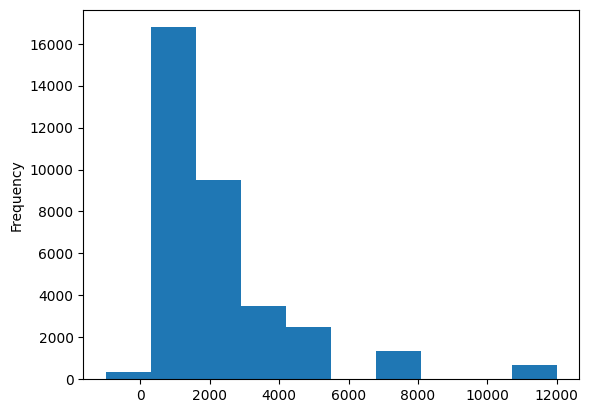

In [191]:
df_master['price'].plot(kind='hist')

<Axes: >

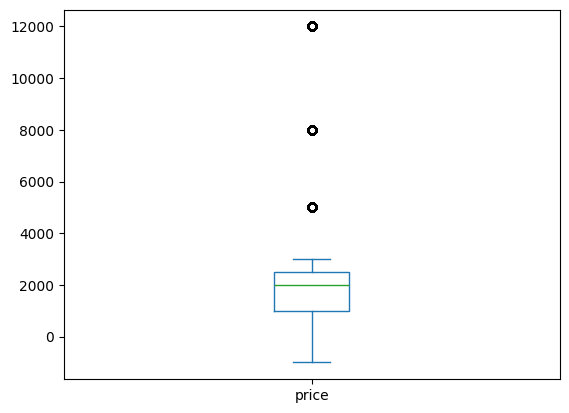

In [192]:
df_master['price'].plot(kind='box')

In [193]:
df_master['price'].describe()

,price
count,34662.000000
mean,2329.260747
std,2161.022053
min,-999.000000
25%,1000.000000
50%,2000.000000
75%,2500.000000
max,12000.000000


In [194]:
 df_master[df_master['price']<0]

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
28,1015663,Arjun,Hyderabad,Entire home,-999.0,2.0,22,1.2,230,2023-09-23,No,Flexible
72,1001189,Suresh,Kolkata,Entire home,-999.0,10.0,32,0.0,26,2024-06-07,Yes,Flexible
172,1021953,John,Kolkata,Entire home,-999.0,2.0,46,NaN,50,2022-04-30,No,Flexible
388,1021049,Karthik,Mumbai,Private room,-999.0,1.0,31,2.5,317,2022-01-14,No,Flexible
389,1027222,Arjun,Delhi,Entire home,-999.0,2.0,27,0.0,296,2022-03-13,Yes,Flexible
...,...,...,...,...,...,...,...,...,...,...,...,...
34666,1020768,Karthik,Chennai,Private room,-999.0,2.0,31,2.5,155,2022-11-18,No,Flexible
34680,1017723,Lakshmi,BANGALORE,Entire home,-999.0,1.0,30,0.0,98,2024-01-03,No,Strict
34728,1016286,unavailable,mumbai,Entire home,-999.0,1.0,35,1.2,168,2023-02-12,Yes,Moderate
34787,1006719,Arjun,Pune,Entire home,-999.0,1.0,32,4.0,188,2022-05-08,No,Flexible


In [200]:
df_master[df_master['price']<0]['price'].unique()

TypeError: '<' not supported between instances of 'method' and 'int'

In [204]:
df_master[df_master['price']<0]['price'].nunique()

TypeError: '<' not supported between instances of 'method' and 'int'

In [197]:
df_master['price']= abs(df_master['price'])

In [198]:
df_master['price']= (df_master['price']).abs

In [114]:
 df_master

,listing_id,host_name,city,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,last_review,host_is_superhost,cancellation_policy
0,1017814,Lakshmi,Pune,Shared room,2000.0,2.0,25,0.5,145,2024-05-04,Yes,Flexible
1,1006858,Karthik,Pune,Entire home,12000.0,2.0,20,0.0,313,2024-10-10,No,Moderate
2,1007673,Ananya,Chennai,Entire home,1500.0,2.0,29,0.5,107,2022-03-11,No,Flexible
3,1009705,Ravi,Hyderabad,Hotel room,500.0,3.0,29,2.5,303,2022-06-24,No,Flexible
4,1014304,unavailable,Bangalore,Entire home,1500.0,3.0,33,0.0,138,2022-03-16,No,Flexible
...,...,...,...,...,...,...,...,...,...,...,...,...
34995,1009289,Ananya,Ahmedabad,Private room,1000.0,5.0,38,0.0,45,2023-05-22,Yes,Moderate
34996,1006812,Ravi,Chennai,Entire home,2000.0,1.0,35,1.2,341,2022-05-20,Yes,Strict
34997,1003894,Priya,Bangalore,Shared room,1500.0,3.0,41,1.2,356,2024-05-30,No,Flexible
34998,1009360,Michael,Chennai,Entire home,5000.0,1.0,41,0.5,229,2022-01-27,No,Moderate




# SEGMENT 3 — MARKET INSIGHTS & LISTING PERFORMANCE ANALYSIS

**Focus:** Business Understanding, Insight Generation, Decision Support

---

## Objective

Analyze the cleaned and standardized listings dataset to generate insights that support AirBnB’s pricing strategy, host performance evaluation, and market-level decision-making.

The emphasis is on **interpreting data, not just computing metrics**.

---

## Tasks (21–30)

---

### Task 21 — Compare Average Listing Prices Across Cities

**Description**
Evaluate how average listing prices vary across cities and identify high-cost and low-cost markets.

**Expected Outcome**
A ranked list of cities based on average listing price.

**Hints**

* Use `groupby()` with aggregation
* Sort results in descending order
* Consider both mean and median for robustness

---

### Task 22 — Analyze Pricing Differences by Room Type

**Description**
Understand how pricing varies by room type across the platform.

**Expected Outcome**
Clear comparison of prices for Entire Home, Private Room, Shared Room, and Hotel Room listings.

**Hints**

* Use `groupby()` on room type
* Aggregate using mean and count
* Validate distribution size before interpreting results

---

### Task 23 — Evaluate the Influence of Superhost Status

**Description**
Assess whether superhost status correlates with higher listing prices.

**Expected Outcome**
A comparison of average prices between superhost and non-superhost listings.

**Hints**

* Group data by `host_is_superhost`
* Compare average prices and listing counts
* Avoid assuming causation from correlation

---

### Task 24 — Identify High-Demand Listings Using Availability

**Description**
Identify listings with consistently low availability, indicating high demand.

**Expected Outcome**
A subset of listings flagged as high-demand.

**Hints**

* Define a threshold for low availability (e.g., < 90 days)
* Use conditional filtering
* Validate proportion of high-demand listings

---

### Task 25 — Analyze Review Volume Trends Across Cities

**Description**
Understand how guest engagement varies across markets using review volume.

**Expected Outcome**
City-level comparison of review counts.

**Hints**

* Aggregate review counts by city
* Use mean and total metrics
* Watch for cities with high listing volume skewing results

---

### Task 26 — Identify Top Performing Listings

**Description**
Identify listings that perform well based on pricing and guest engagement.

**Expected Outcome**
A ranked list of high-performing listings.

**Hints**

* Combine price and number of reviews
* Sort by multiple columns
* Limit output to top performers for clarity

---

### Task 27 — Create City × Room Type Pricing Matrix (Pivot)

**Description**
Generate a matrix showing average prices by city and room type.

**Expected Outcome**
A pivot table suitable for pricing strategy discussions.

**Hints**

* Use `pd.pivot_table()`
* Set city as index and room type as columns
* Use mean as aggregation function

---

### Task 28 — Examine Seasonal Patterns Using Review Activity

**Description**
Analyze how review activity varies across time to identify seasonal trends.

**Expected Outcome**
Monthly or yearly review activity trends.

**Hints**

* Use derived year and month features
* Aggregate review counts by time period
* Interpret trends cautiously for incomplete periods

---

### Task 29 — Detect Pricing Outliers

**Description**
Identify unusually priced listings and consider possible operational explanations.

**Expected Outcome**
A set of outlier listings with contextual interpretation.

**Hints**

* Use quantiles or IQR-based thresholds
* Compare outliers by city and room type
* Avoid removing outliers unless justified

---

### Task 30 — Produce Market Summary for Leadership

**Description**
Summarize analytical findings into clear, actionable insights suitable for decision-makers.

**Expected Outcome**
A concise narrative highlighting key pricing and demand insights.

**Hints**

* Focus on implications, not just numbers
* Highlight market differences and trends
* Keep insights grounded in data evidence

---

## Segment 3 Deliverable

* Aggregated tables and pivot outputs
* Ranked analytical summaries
* A written market insight summary

---

## What This Segment Evaluates

* Analytical reasoning
* Pandas aggregation and pivoting skills
* Business interpretation of data
* Communication clarity

---
